In [ ]:
## Markdown
# Category Inflow Heatmap (2022–2025)

## Objective
- Visualize monthly net inflows across mutual fund categories.
- Create a heatmap using Seaborn.
- X-axis: Months
- Y-axis: Fund Categories
- Color Intensity: Net Inflow (₹ Crore)


In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
# Load dataset
df = pd.read_csv("../data/processed/05_category_inflows_clean.csv")

In [3]:
# Check dataset
print(df.shape)

print(df.columns)

df.head()

(144, 3)
Index(['month', 'category', 'net_inflow_crore'], dtype='object')


,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [4]:
# Convert month
df["month"] = pd.to_datetime(df["month"])

df.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [5]:
# Create pivot table
heatmap_data = df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


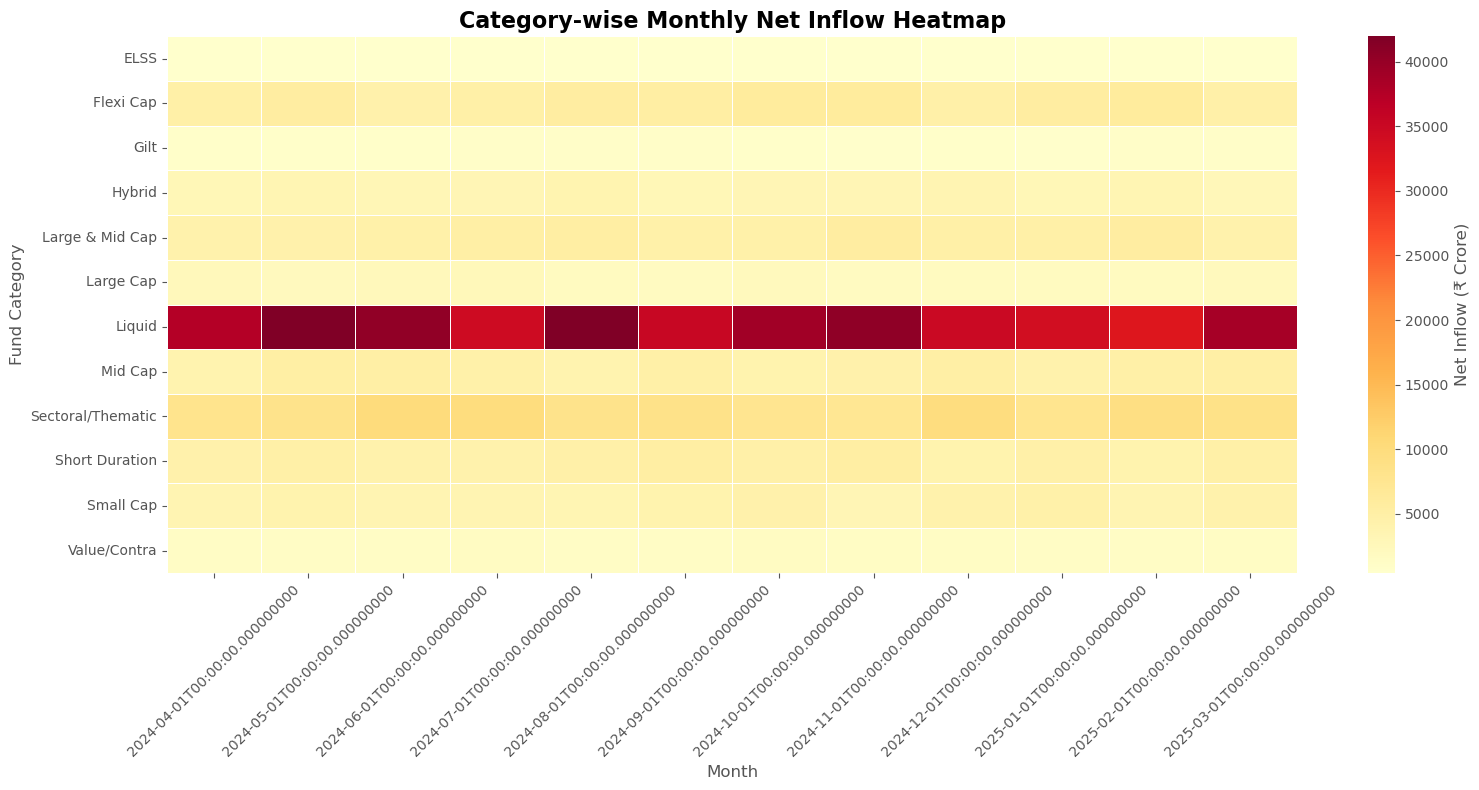

In [9]:
# Plot heatmap
plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.5,
    annot=False,
    cbar_kws={"label": "Net Inflow (₹ Crore)"}
)

plt.title(
    "Category-wise Monthly Net Inflow Heatmap",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

# Save Image
plt.savefig(
    "../reports/04_category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

# Show Graph
plt.show()